# 05 — EDA: T-100 Domestic

Monthly aggregate traffic and capacity for **domestic** routes at IAD, DCA, BWI.
Granularity: one row per carrier × origin × destination × month.
Same raw source as the international T-100 (FMG, `cboGeography=All`) — domestic rows
are filtered by `ORIGIN_COUNTRY == DEST_COUNTRY == 'US'`.

**Key columns not in the on-time dataset:**
- `PASSENGERS` — actual passengers boarded (not available in on-time data)
- `SEATS` — seats offered; enables load factor calculation
- `DEPARTURES_PERFORMED` — actual departures flown

**Scope:** Scheduled service (CLASS=F) only; outbound departures from IAD/DCA/BWI.
Note: T-100 does not record individual itineraries — connecting passengers appear
as separate legs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from config import PROCESSED_DATA_PATH

sns.set_theme(style='whitegrid', palette='muted')
AIRPORTS = ['IAD', 'DCA', 'BWI']
AIRPORT_NAMES = {'IAD': 'Dulles (IAD)', 'DCA': 'Reagan (DCA)', 'BWI': 'BWI'}
COLORS = {'IAD': '#1f77b4', 'DCA': '#ff7f0e', 'BWI': '#2ca02c'}
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

df = pd.read_parquet(PROJECT_ROOT / PROCESSED_DATA_PATH / 't100_domestic_dmv.parquet')
sched = df[df['CLASS'] == 'F'].copy()

print(f'Total rows (all classes): {len(df):,}')
print(f'Scheduled service rows:   {len(sched):,}')
print()
print('CLASS breakdown (passengers):')
print(df.groupby('CLASS')['PASSENGERS'].sum().sort_values(ascending=False).apply(lambda x: f'{x:,.0f}'))

Total rows (all classes): 132,305
Scheduled service rows:   118,377

CLASS breakdown (passengers):
CLASS
F    317,323,500
L        604,133
P             82
G              0
Name: PASSENGERS, dtype: object


## Section 1 — Domestic passenger volume by airport × year

Total scheduled outbound domestic passengers, 2015–2025. Note that BWI and DCA
carry more domestic passengers than IAD — IAD's volume is concentrated in fewer,
longer international routes.

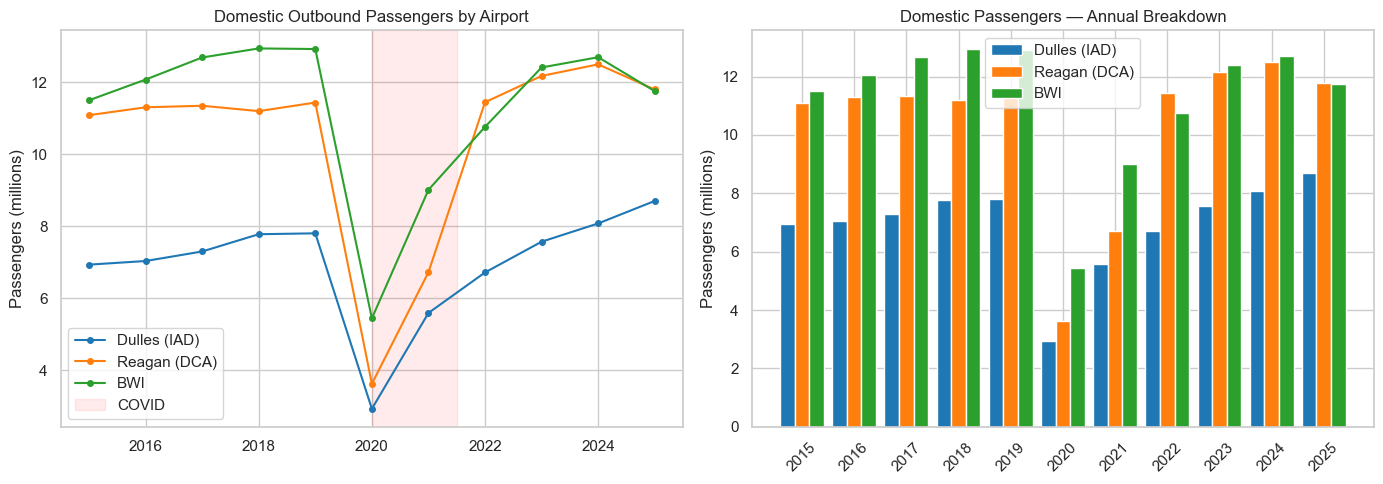

Annual domestic passengers (M):
ORIGIN    BWI    DCA   IAD
YEAR                      
2015    11.50  11.08  6.94
2016    12.07  11.30  7.04
2017    12.68  11.35  7.30
2018    12.94  11.20  7.78
2019    12.92  11.43  7.81
2020     5.45   3.63  2.94
2021     9.01   6.73  5.60
2022    10.76  11.44  6.72
2023    12.41  12.17  7.57
2024    12.69  12.49  8.08
2025    11.75  11.80  8.70


In [2]:
pax_yr = (
    sched[sched['YEAR'] <= 2025]
    .groupby(['YEAR', 'ORIGIN'])['PASSENGERS']
    .sum()
    .unstack()
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for ap in AIRPORTS:
    ax.plot(pax_yr.index, pax_yr[ap] / 1e6, marker='o', ms=4,
            label=AIRPORT_NAMES[ap], color=COLORS[ap])
ax.axvspan(2020, 2021.5, alpha=0.08, color='red', label='COVID')
ax.set_title('Domestic Outbound Passengers by Airport')
ax.set_ylabel('Passengers (millions)')
ax.legend()

ax = axes[1]
width = 0.28
years = pax_yr.index.tolist()
x = np.arange(len(years))
for i, ap in enumerate(AIRPORTS):
    ax.bar(x + i * width, pax_yr[ap] / 1e6, width,
           label=AIRPORT_NAMES[ap], color=COLORS[ap])
ax.set_xticks(x + width)
ax.set_xticklabels(years, rotation=45)
ax.set_title('Domestic Passengers — Annual Breakdown')
ax.set_ylabel('Passengers (millions)')
ax.legend()

plt.tight_layout()
plt.show()

print('Annual domestic passengers (M):')
print((pax_yr / 1e6).round(2))

## Section 2 — Load factor by airport × year

Weighted load factor = total passengers / total seats. Measures how efficiently
each airport fills its domestic capacity. BWI's high load factor reflects Southwest's
point-to-point leisure model with minimal schedule padding.

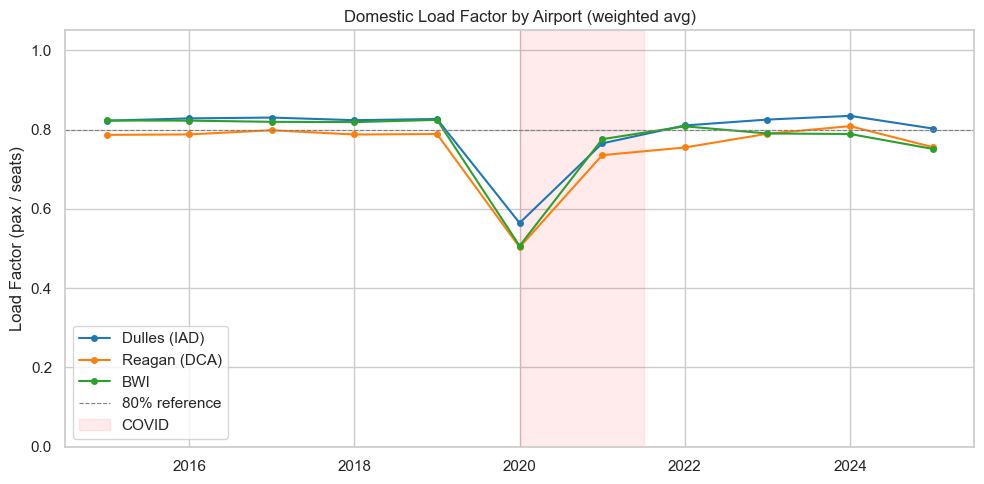

Weighted load factor:
ORIGIN    BWI    DCA    IAD
YEAR                       
2015    0.823  0.787  0.822
2016    0.823  0.788  0.828
2017    0.820  0.798  0.830
2018    0.819  0.788  0.824
2019    0.824  0.789  0.827
2020    0.507  0.503  0.564
2021    0.776  0.735  0.765
2022    0.808  0.755  0.810
2023    0.790  0.789  0.825
2024    0.789  0.809  0.835
2025    0.751  0.756  0.803


In [3]:
valid = sched[sched['SEATS'] > 0]
lf_num = valid[valid['YEAR'] <= 2025].groupby(['YEAR', 'ORIGIN'])['PASSENGERS'].sum()
lf_den = valid[valid['YEAR'] <= 2025].groupby(['YEAR', 'ORIGIN'])['SEATS'].sum()
lf = (lf_num / lf_den).unstack().fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
for ap in AIRPORTS:
    ax.plot(lf.index, lf[ap], marker='o', ms=4,
            label=AIRPORT_NAMES[ap], color=COLORS[ap])
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, label='80% reference')
ax.axvspan(2020, 2021.5, alpha=0.08, color='red', label='COVID')
ax.set_title('Domestic Load Factor by Airport (weighted avg)')
ax.set_ylabel('Load Factor (pax / seats)')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

print('Weighted load factor:')
print(lf.round(3))

## Section 3 — Top domestic routes per airport

This is the key analysis unlocked by T-100 that the on-time dataset cannot provide:
actual passenger volumes on specific routes. The on-time data has flight counts;
T-100 has how many people were on those flights.

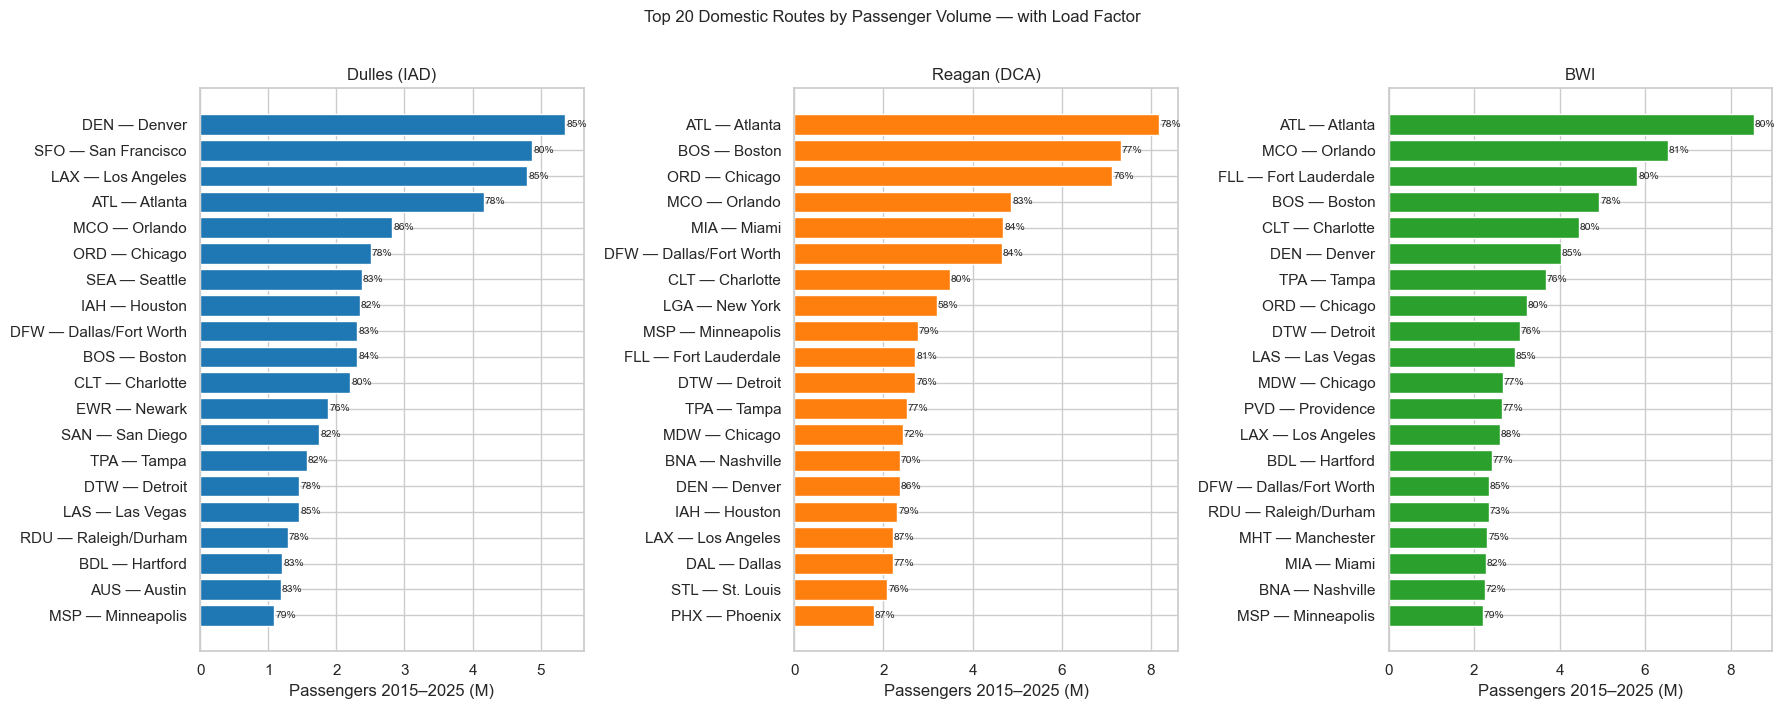

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, ap in zip(axes, AIRPORTS):
    sub = sched[sched['ORIGIN'] == ap]
    top = (
        sub.groupby('DEST')
        .agg(pax=('PASSENGERS', 'sum'), lf=('PASSENGERS', 'sum'))
        .join(sub.groupby('DEST')['SEATS'].sum().rename('seats'))
        .assign(load_factor=lambda d: d['pax'] / d['seats'])
        .sort_values('pax', ascending=False)
        .head(20)
        .sort_values('pax')
    )
    city_map = sub.groupby('DEST')['DEST_CITY_NAME'].first()
    labels = [
        f"{dest} — {city_map.get(dest, dest).split(',')[0]}"
        for dest in top.index
    ]
    bars = ax.barh(labels, top['pax'] / 1e6, color=COLORS[ap])
    for bar, lf_val in zip(bars, top['load_factor']):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{lf_val:.0%}', va='center', fontsize=7.5)
    ax.set_title(AIRPORT_NAMES[ap])
    ax.set_xlabel('Passengers 2015–2025 (M)')
    ax.set_ylabel('')

fig.suptitle('Top 20 Domestic Routes by Passenger Volume — with Load Factor', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Section 4 — Carrier share of domestic passengers per airport

Southwest carries 70% of BWI's domestic passengers — one of the highest hub
concentrations of any large US airport. United (with its United Express feeders
Mesa and CommuteAir) controls ~65% of IAD. DCA is the most fragmented, with
American's dominance tempered by Southwest, Delta, and regional carriers.

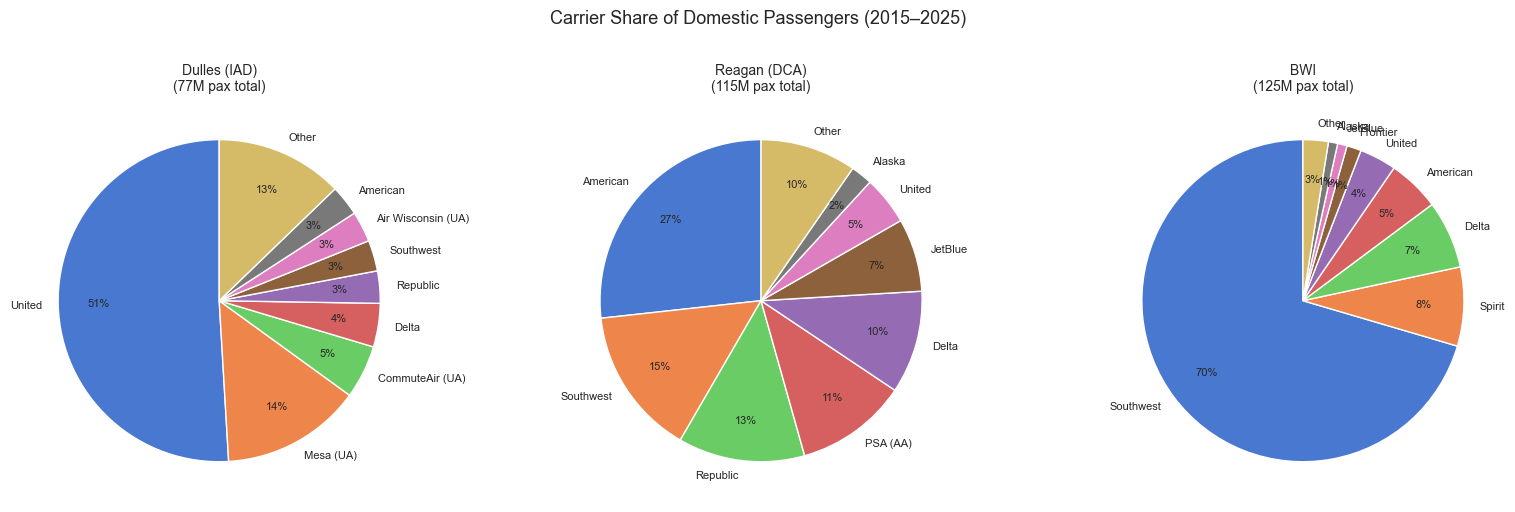

Carrier share detail:

Dulles (IAD) (77.0M total):
  United                  39.2M  (51%)
  Mesa (UA)               10.8M  (14%)
  CommuteAir (UA)          4.1M  (5%)
  Delta                    3.4M  (4%)
  Republic                 2.5M  (3%)
  Southwest                2.4M  (3%)

Reagan (DCA) (115.4M total):
  American                30.9M  (27%)
  Southwest               17.2M  (15%)
  Republic                14.7M  (13%)
  PSA (AA)                13.0M  (11%)
  Delta                   11.9M  (10%)
  JetBlue                  8.5M  (7%)

BWI (124.9M total):
  Southwest               88.0M  (70%)
  Spirit                   9.9M  (8%)
  Delta                    8.5M  (7%)
  American                 6.5M  (5%)
  United                   4.6M  (4%)
  Frontier                 1.8M  (1%)


In [5]:
SHORT_NAMES = {
    'Southwest Airlines Co.': 'Southwest',
    'United Air Lines Inc.': 'United',
    'American Airlines Inc.': 'American',
    'Delta Air Lines Inc.': 'Delta',
    'Republic Airline': 'Republic',
    'PSA Airlines Inc.': 'PSA (AA)',
    'JetBlue Airways': 'JetBlue',
    'Spirit Air Lines': 'Spirit',
    'Alaska Airlines Inc.': 'Alaska',
    'Frontier Airlines Inc.': 'Frontier',
    'Mesa Airlines Inc.': 'Mesa (UA)',
    'CommuteAir LLC dba CommuteAir': 'CommuteAir (UA)',
    'Air Wisconsin Airlines Corp': 'Air Wisconsin (UA)',
    'Endeavor Air Inc.': 'Endeavor (DL)',
    'Trans States Airlines': 'Trans States',
    'SkyWest Airlines Inc.': 'SkyWest',
}

TOP_N = 8
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ap in zip(axes, AIRPORTS):
    sub = sched[sched['ORIGIN'] == ap]
    carr = sub.groupby('UNIQUE_CARRIER_NAME')['PASSENGERS'].sum().sort_values(ascending=False)
    top = carr.head(TOP_N).copy()
    other = carr.iloc[TOP_N:].sum()
    if other > 0:
        top['Other'] = other
    total = top.sum()
    top.index = [SHORT_NAMES.get(n, n) for n in top.index]

    wedges, texts, autotexts = ax.pie(
        top.values, labels=top.index, autopct='%1.0f%%',
        startangle=90, pctdistance=0.75,
        textprops={'fontsize': 8}
    )
    ax.set_title(f'{AIRPORT_NAMES[ap]}\n({total/1e6:.0f}M pax total)', fontsize=10)

fig.suptitle('Carrier Share of Domestic Passengers (2015–2025)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Carrier share detail:')
for ap in AIRPORTS:
    sub = sched[sched['ORIGIN'] == ap]
    total = sub['PASSENGERS'].sum()
    top = sub.groupby('UNIQUE_CARRIER_NAME')['PASSENGERS'].sum().sort_values(ascending=False).head(6)
    print(f'\n{AIRPORT_NAMES[ap]} ({total/1e6:.1f}M total):')
    for name, pax in top.items():
        print(f'  {SHORT_NAMES.get(name, name):<22} {pax/1e6:5.1f}M  ({pax/total*100:.0f}%)')

## Section 5 — COVID recovery

All three airports lost ~60–70% of domestic traffic in 2020. BWI recovered
fastest — Southwest's leisure-heavy network rebounded earlier than the
business-travel-dependent IAD and DCA.

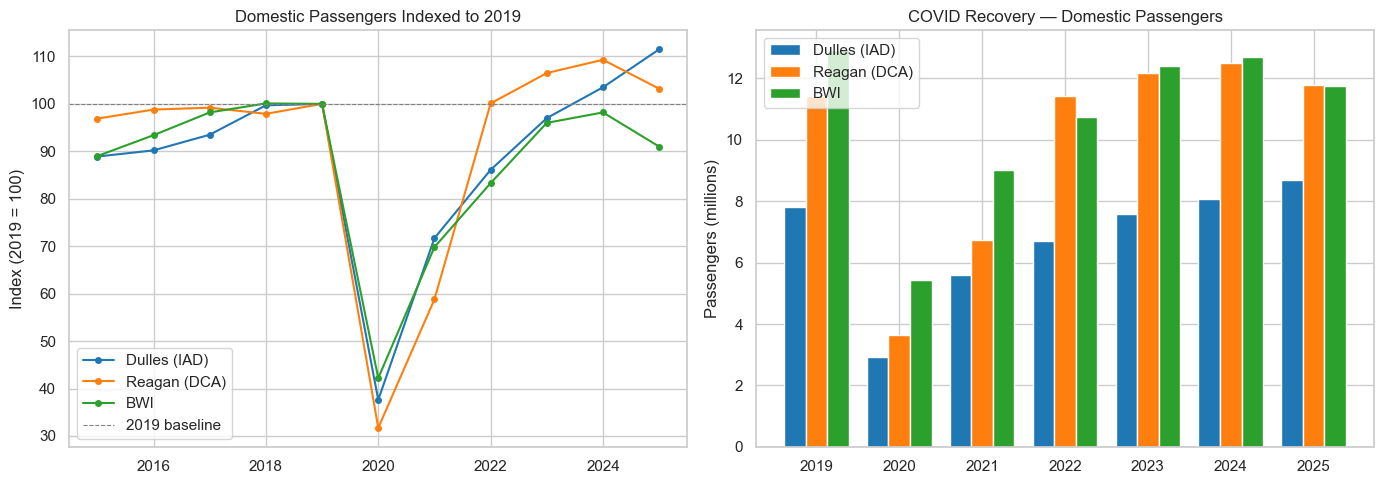

Recovery index (2019 = 100):
ORIGIN    BWI    DCA    IAD
YEAR                       
2019    100.0  100.0  100.0
2020     42.2   31.7   37.6
2021     69.8   58.8   71.7
2022     83.3  100.1   86.1
2023     96.0  106.5   97.0
2024     98.2  109.3  103.5
2025     91.0  103.2  111.5


In [6]:
pax_all = (
    sched[sched['YEAR'] <= 2025]
    .groupby(['YEAR', 'ORIGIN'])['PASSENGERS']
    .sum()
    .unstack()
    .fillna(0)
)
base_2019 = pax_all.loc[2019]
indexed = (pax_all / base_2019 * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for ap in AIRPORTS:
    ax.plot(indexed.index, indexed[ap], marker='o', ms=4,
            label=AIRPORT_NAMES[ap], color=COLORS[ap])
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, label='2019 baseline')
ax.set_title('Domestic Passengers Indexed to 2019')
ax.set_ylabel('Index (2019 = 100)')
ax.legend()

ax = axes[1]
covid_years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]
width = 0.26
x = np.arange(len(covid_years))
for i, ap in enumerate(AIRPORTS):
    ax.bar(x + i * width, pax_all.loc[covid_years, ap] / 1e6, width,
           label=AIRPORT_NAMES[ap], color=COLORS[ap])
ax.set_xticks(x + width)
ax.set_xticklabels(covid_years)
ax.set_title('COVID Recovery — Domestic Passengers')
ax.set_ylabel('Passengers (millions)')
ax.legend()

plt.tight_layout()
plt.show()

print('Recovery index (2019 = 100):')
print(indexed.loc[2019:].to_string())

## Section 6 — Seasonal pattern — monthly domestic passengers

Pre-COVID baseline (2015–2019 average). Domestic seasonality is more pronounced
than international — summer leisure travel drives a clear July/August peak,
especially at BWI where Southwest's leisure routes amplify the effect.

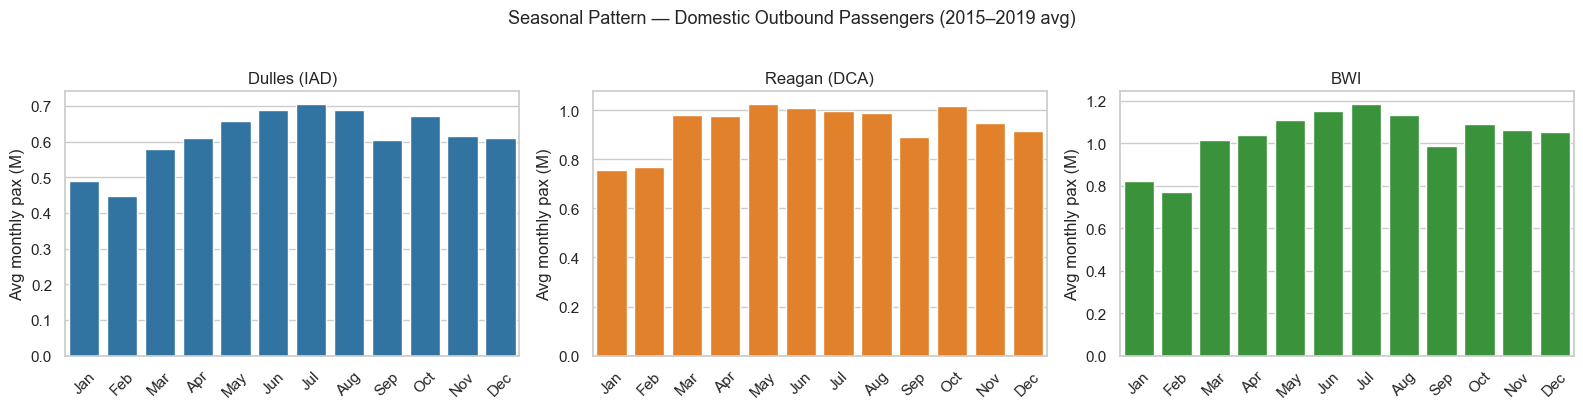

In [7]:
pre = sched[sched['YEAR'].between(2015, 2019)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, ap in zip(axes, AIRPORTS):
    sub = pre[pre['ORIGIN'] == ap]
    monthly = sub.groupby('MONTH')['PASSENGERS'].sum() / 5
    monthly.index = MONTH_LABELS
    sns.barplot(x=monthly.index, y=monthly.values / 1e6, ax=ax, color=COLORS[ap])
    ax.set_title(AIRPORT_NAMES[ap])
    ax.set_xlabel('')
    ax.set_ylabel('Avg monthly pax (M)')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Seasonal Pattern — Domestic Outbound Passengers (2015–2019 avg)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Section 7 — Carrier dominance on key routes

Which carrier owns each high-volume route? Shows that Southwest holds near-monopoly
positions on many BWI leisure routes (BWI→MCO, BWI→FLL) while IAD routes are
almost entirely United or its regional feeders.

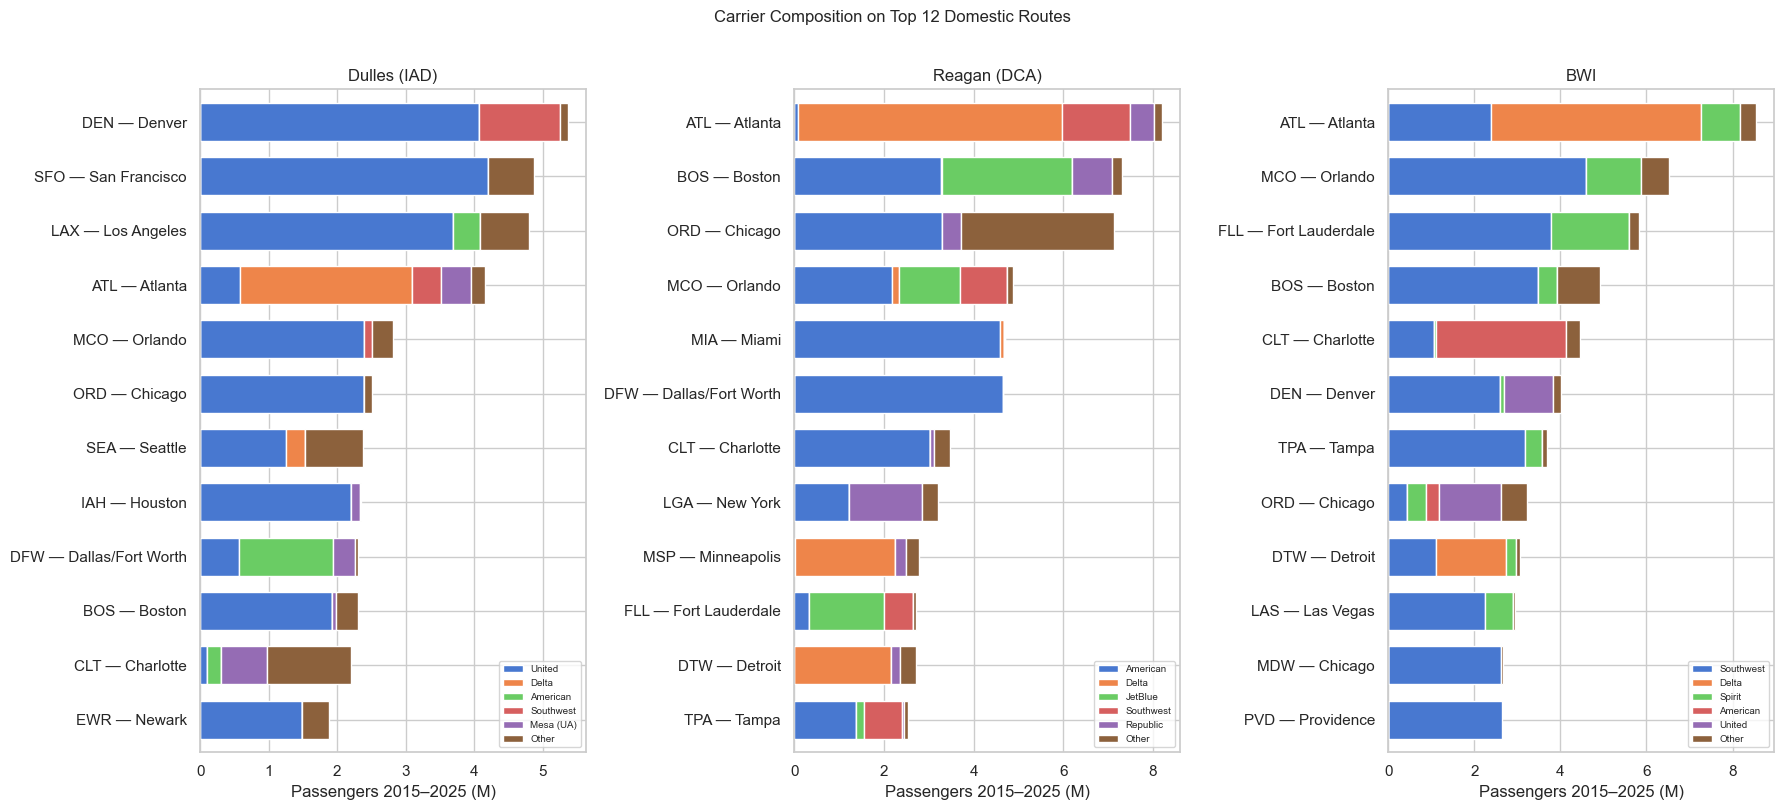

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, ap in zip(axes, AIRPORTS):
    sub = sched[sched['ORIGIN'] == ap]
    top_dests = (
        sub.groupby('DEST')['PASSENGERS'].sum()
        .sort_values(ascending=False)
        .head(12)
        .index.tolist()
    )
    route_carr = (
        sub[sub['DEST'].isin(top_dests)]
        .groupby(['DEST', 'UNIQUE_CARRIER_NAME'])['PASSENGERS']
        .sum()
        .unstack(fill_value=0)
    )
    # Keep top 5 carriers across all routes, collapse rest
    top_carrs = route_carr.sum().sort_values(ascending=False).head(5).index
    other = route_carr.drop(columns=top_carrs).sum(axis=1)
    plot_df = route_carr[top_carrs].copy()
    if other.any():
        plot_df['Other'] = other
    plot_df.columns = [SHORT_NAMES.get(c, c) for c in plot_df.columns]

    # Sort rows by total pax descending
    plot_df = plot_df.loc[top_dests[::-1]]
    city_map = sub.groupby('DEST')['DEST_CITY_NAME'].first()
    plot_df.index = [
        f"{d} — {city_map.get(d, d).split(',')[0]}" for d in plot_df.index
    ]
    plot_df.div(1e6).plot(kind='barh', stacked=True, ax=ax, width=0.7)
    ax.set_title(AIRPORT_NAMES[ap])
    ax.set_xlabel('Passengers 2015–2025 (M)')
    ax.set_ylabel('')
    ax.legend(fontsize=7, loc='lower right')

fig.suptitle('Carrier Composition on Top 12 Domestic Routes', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Section 8 — United Express feeders at IAD

IAD's United Express regional carriers (Mesa, CommuteAir, Air Wisconsin) collectively
carry ~20% of IAD's domestic passengers. This section shows their volume over time
and which routes they cover — typically shorter-haul spokes that feed United's
long-haul operations.

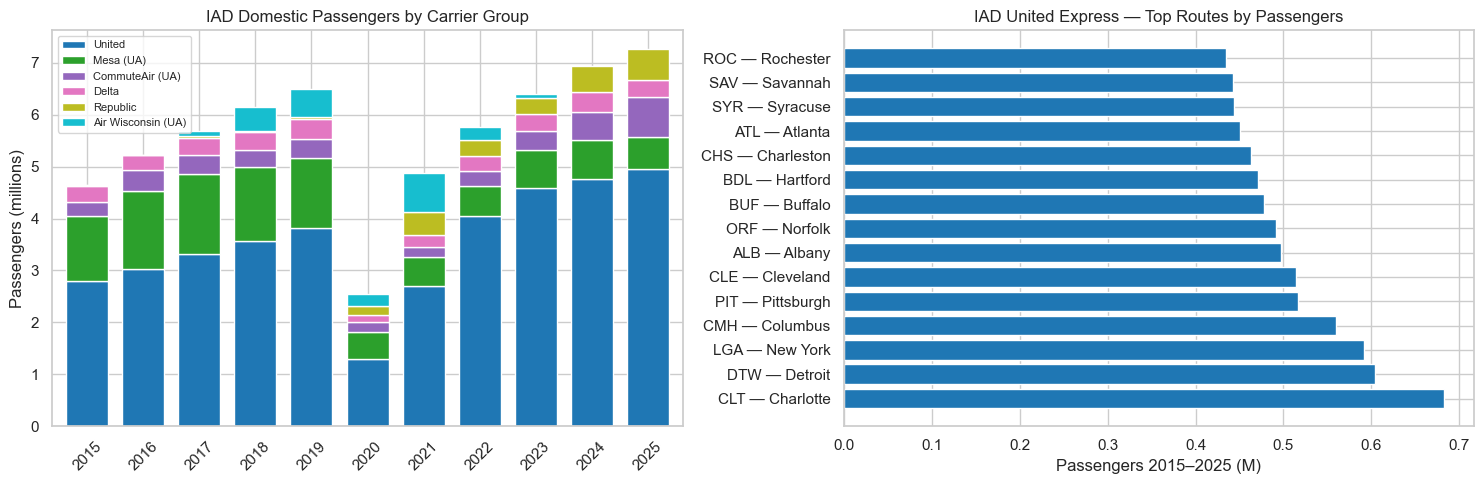

In [9]:
EXPRESS_CODES = {'YV': 'Mesa (UA)', 'C5': 'CommuteAir (UA)',
                 'ZW': 'Air Wisconsin (UA)', 'AX': 'Trans States (UA)'}

iad = sched[sched['ORIGIN'] == 'IAD'].copy()

# Build carrier-code → group name map without per-row DataFrame lookups
code_to_name = iad.groupby('UNIQUE_CARRIER')['UNIQUE_CARRIER_NAME'].first().to_dict()
def carrier_group(code):
    if code == 'UA':
        return 'United'
    if code in EXPRESS_CODES:
        return EXPRESS_CODES[code]
    return SHORT_NAMES.get(code_to_name.get(code, code), code_to_name.get(code, code))

iad['carrier_group'] = iad['UNIQUE_CARRIER'].map(carrier_group)

grp_yr = (
    iad[iad['YEAR'] <= 2025]
    .groupby(['YEAR', 'carrier_group'])['PASSENGERS']
    .sum()
    .unstack(fill_value=0)
)
top_groups = grp_yr.sum().sort_values(ascending=False).head(6).index
grp_yr = grp_yr[top_groups]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
grp_yr.div(1e6).plot(kind='bar', stacked=True, ax=ax, width=0.75, colormap='tab10')
ax.set_title('IAD Domestic Passengers by Carrier Group')
ax.set_ylabel('Passengers (millions)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)

ax = axes[1]
express = iad[iad['UNIQUE_CARRIER'].isin(EXPRESS_CODES)]
top_express_routes = (
    express.groupby('DEST')['PASSENGERS'].sum()
    .sort_values(ascending=False)
    .head(15)
)
city_map = express.groupby('DEST')['DEST_CITY_NAME'].first()
labels = [f"{d} — {city_map.get(d, d).split(',')[0]}" for d in top_express_routes.index]
ax.barh(labels, top_express_routes.values / 1e6, color=COLORS['IAD'])
ax.set_title('IAD United Express — Top Routes by Passengers')
ax.set_xlabel('Passengers 2015–2025 (M)')

plt.tight_layout()
plt.show()

## Section 9 — Quarterly seasonality

Pre-COVID baseline (2015–2019). Domestic seasonality peaks in Q3 (summer)
and troughs in Q1 (winter), consistent with leisure travel patterns.

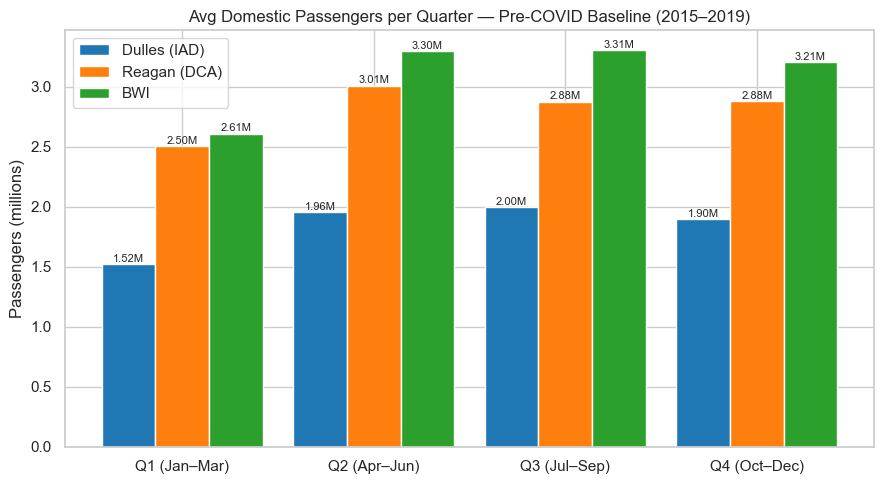

In [10]:
pre = sched[sched['YEAR'].between(2015, 2019)]

q_pax = (
    pre.groupby(['QUARTER', 'ORIGIN'])['PASSENGERS']
    .sum()
    .unstack()
) / 5  # avg per year

fig, ax = plt.subplots(figsize=(9, 5))
x = [1, 2, 3, 4]
width = 0.28
for i, ap in enumerate(AIRPORTS):
    ax.bar([xi + i * width for xi in x], q_pax[ap] / 1e6, width,
           label=AIRPORT_NAMES[ap], color=COLORS[ap])
    for xi, val in zip(x, q_pax[ap]):
        ax.text(xi + i * width, val / 1e6 + 0.02, f'{val/1e6:.2f}M',
                ha='center', fontsize=8)
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(['Q1 (Jan–Mar)', 'Q2 (Apr–Jun)', 'Q3 (Jul–Sep)', 'Q4 (Oct–Dec)'])
ax.set_title('Avg Domestic Passengers per Quarter — Pre-COVID Baseline (2015–2019)')
ax.set_ylabel('Passengers (millions)')
ax.legend()
plt.tight_layout()
plt.show()

## Section 10 — Summary table

Key domestic metrics per airport — pre-COVID vs post-COVID comparison.

In [11]:
pre = sched[sched['YEAR'].between(2015, 2019)]
post = sched[sched['YEAR'].between(2023, 2025)]

rows = []
for ap in AIRPORTS:
    def stats(subset):
        s = subset[subset['ORIGIN'] == ap]
        pax = s['PASSENGERS'].sum()
        seats = s['SEATS'].sum()
        lf = pax / seats if seats > 0 else 0
        routes = s['DEST'].nunique()
        top_carrier = (
            s.groupby('UNIQUE_CARRIER_NAME')['PASSENGERS'].sum().idxmax()
        )
        top_share = (
            s.groupby('UNIQUE_CARRIER_NAME')['PASSENGERS'].sum().max() / pax
        )
        return {
            'pax_M': pax / 1e6, 'load_factor': lf,
            'unique_routes': routes,
            'top_carrier': SHORT_NAMES.get(top_carrier, top_carrier),
            'top_share': top_share,
        }

    p = stats(pre)
    q = stats(post)
    rows.append({
        'Airport': AIRPORT_NAMES[ap],
        'Pre-COVID pax/yr (M)': f"{p['pax_M']/5:.1f}",
        'Post-COVID pax/yr (M)': f"{q['pax_M']/3:.1f}",
        'Pre LF': f"{p['load_factor']:.3f}",
        'Post LF': f"{q['load_factor']:.3f}",
        'Routes': p['unique_routes'],
        'Top carrier': p['top_carrier'],
        'Top share': f"{p['top_share']:.0%}",
    })

summary = pd.DataFrame(rows).set_index('Airport')
print(summary.to_string())

             Pre-COVID pax/yr (M) Post-COVID pax/yr (M) Pre LF Post LF  Routes Top carrier Top share
Airport                                                                                             
Dulles (IAD)                  7.4                   8.1  0.826   0.820     166      United       45%
Reagan (DCA)                 11.3                  12.2  0.790   0.785     153    American       25%
BWI                          12.4                  12.3  0.822   0.777     157   Southwest       69%
